## 라이브러리 호출 및 데이터 로드

In [1]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json
from pprint import pprint
import warnings
import platform

# 통계용 라이브러리 호출
from scipy import stats
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from matplotlib.patches import Patch
import pingouin as pg
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

---
---


### 평균등수 -y축 변경
##### 챔피언-aurelionsol 지우고/ 시너지-Starship

In [26]:

combo_stats_by_tier = pd.read_csv('../../rrere/유저단위/combination_stats_by_tier.csv')
champ_stats = pd.read_csv('../../rrere/유저단위/champ_stats.csv')
champ_item_pivot = pd.read_csv('../../rrere/유저단위/champion_item_top3.csv')

champ_stats_by_tier = pd.read_csv('../../rrere/유저단위/champion_stats_by_tier.csv')
combo_stats = pd.read_csv('../../rrere/유저단위/combination_stats.csv')

In [ ]:
# # star ship 지우기
# combo_stats_by_tier_except = combo_stats_by_tier.drop(
#     combo_stats_by_tier[combo_stats_by_tier['combo_list_active'] == 'Starship'].index
# )

# print("Starship 남은 개수:", (combo_stats_by_tier_except['combo_list_active'] == 'Starship').sum())


Starship 남은 개수: 0


In [ ]:

# # aurelionsol 지우기
# champ_stats_by_tier_except = champ_stats_by_tier.drop(
#     champ_stats_by_tier[champ_stats_by_tier['name'] == 'aurelionsol'].index
# )

# print("aurelionsol 남은 개수:", (champ_stats_by_tier_except ['name'] == 'aurelionsol').sum())

aurelionsol 남은 개수: 0


In [ ]:
# 아우솔 및 스타십 지우지 않은 버전 사용하기 위해서 활성화 필요
# 아닌 경우 위의 지우는 코드 활성화

# combo_stats_by_tier_except = combo_stats_by_tier
# champ_stats_by_tier_except = champ_stats_by_tier

---
---
#### **3/28 작업 내용**

##### **(1) 티어별 챔피언 승률/선택률 분포(의사결정 사분면 제작용)**

In [28]:
# 왜도(skewness) 확인 → 0에 가까울수록 정규분포에 가까움
print(f"win_rate  왜도: {champ_stats_by_tier_except['win_rate'].skew():.3f}")
print(f"pick_rate 왜도: {champ_stats_by_tier_except['pick_rate'].skew():.3f}")

print(f"avg_rank  왜도: {champ_stats_by_tier_except['avg_rank'].skew():.3f}")

win_rate  왜도: 0.889
pick_rate 왜도: 0.541
avg_rank  왜도: -0.907


In [30]:
# avg_rank version
# ================================
# 티어별 IQR 기반 이상치 탐지 - 데이터 개수가 너무 적어서 확인용
# ================================
tiers_1 = champ_stats_by_tier_except['user_tier'].unique()
result_list_1 = []

for tier_1 in tiers_1:
    tier_df_1 = champ_stats_by_tier_except[champ_stats_by_tier_except['user_tier'] == tier_1].copy()
    
    # win_rate IQR
    Q1_w_s, Q3_w_s = tier_df_1['avg_rank'].quantile(0.25), tier_df_1['avg_rank'].quantile(0.75)
    IQR_w_s = Q3_w_s - Q1_w_s
    tier_df_1['avg_rank_outlier'] = (
        (tier_df_1['avg_rank'] < Q1_w_s - 1.5 * IQR_w_s) |
        (tier_df_1['avg_rank'] > Q3_w_s + 1.5 * IQR_w_s)
    )
    
    # pick_rate IQR
    Q1_p_s, Q3_p_s = tier_df_1['pick_rate'].quantile(0.25), tier_df_1['pick_rate'].quantile(0.75)
    IQR_p_s = Q3_p_s - Q1_p_s
    tier_df_1['pick_rate_outlier'] = (
        (tier_df_1['pick_rate'] < Q1_p_s - 1.5 * IQR_p_s) |
        (tier_df_1['pick_rate'] > Q3_p_s + 1.5 * IQR_p_s)
    )
    
    # 둘 다 이상치일 때만
    tier_df_1['is_outlier'] = tier_df_1['avg_rank_outlier'] & tier_df_1['pick_rate_outlier']
    
    result_list_1.append(tier_df_1)

result_df_1 = pd.concat(result_list_1, ignore_index=True)

# 결과 확인
outliers = result_df_1[result_df_1['is_outlier']].sort_values(['user_tier', 'win_rate'], ascending=[True, False])
print(outliers[['name', 'user_tier', 'avg_rank', 'pick_rate']])
print(f"\n총 이상치 수: {result_df_1['is_outlier'].sum()}개")

Empty DataFrame
Columns: [name, user_tier, avg_rank, pick_rate]
Index: []

총 이상치 수: 0개


In [31]:
# ================================
# 티어별 IQR 기반 이상치 탐지 - 데이터 개수가 너무 적어서 확인용
# ================================
tiers_1 = champ_stats_by_tier_except['user_tier'].unique()
result_list_1 = []

for tier_1 in tiers_1:
    tier_df_1 = champ_stats_by_tier_except[champ_stats_by_tier_except['user_tier'] == tier_1].copy()
    
    # win_rate IQR
    Q1_w_s, Q3_w_s = tier_df_1['win_rate'].quantile(0.25), tier_df_1['win_rate'].quantile(0.75)
    IQR_w_s = Q3_w_s - Q1_w_s
    tier_df_1['win_rate_outlier'] = (
        (tier_df_1['win_rate'] < Q1_w_s - 1.5 * IQR_w_s) |
        (tier_df_1['win_rate'] > Q3_w_s + 1.5 * IQR_w_s)
    )
    
    # pick_rate IQR
    Q1_p_s, Q3_p_s = tier_df_1['pick_rate'].quantile(0.25), tier_df_1['pick_rate'].quantile(0.75)
    IQR_p_s = Q3_p_s - Q1_p_s
    tier_df_1['pick_rate_outlier'] = (
        (tier_df_1['pick_rate'] < Q1_p_s - 1.5 * IQR_p_s) |
        (tier_df_1['pick_rate'] > Q3_p_s + 1.5 * IQR_p_s)
    )
    
    # 둘 다 이상치일 때만
    tier_df_1['is_outlier'] = tier_df_1['win_rate_outlier'] & tier_df_1['pick_rate_outlier']
    
    result_list_1.append(tier_df_1)

result_df_1 = pd.concat(result_list_1, ignore_index=True)

# 결과 확인
outliers = result_df_1[result_df_1['is_outlier']].sort_values(['user_tier', 'win_rate'], ascending=[True, False])
print(outliers[['name', 'user_tier', 'win_rate', 'pick_rate']])
print(f"\n총 이상치 수: {result_df_1['is_outlier'].sum()}개")

Empty DataFrame
Columns: [name, user_tier, win_rate, pick_rate]
Index: []

총 이상치 수: 0개


avg_rank 기준선 (중앙값): 4.439
pick_rate 기준선 (중앙값): 0.139

========== 의사결정 매트릭스 ==========

높은 평균 순위 + 높은 선택률 (86개)
       name    user_tier  avg_rank  pick_rate  is_outlier
       lulu   challenger  3.580707   0.176664       False
       lulu grand_master  3.583215   0.150226       False
       lulu     platinum  3.599041   0.157138       False
       lulu       master  3.637232   0.159815       False
missfortune     platinum  3.748716   0.225239       False
     thresh      diamond  3.753275   0.153695       False
     thresh grand_master  3.779857   0.192488       False
     thresh       master  3.788920   0.177280       False
missfortune      diamond  3.820154   0.270401       False
     thresh   challenger  3.826861   0.205243       False
missfortune       master  3.877075   0.265232       False
missfortune grand_master  3.916105   0.285793       False
       ekko   challenger  3.939495   0.146209       False
missfortune   challenger  3.956653   0.281732       False
    chogath     pla

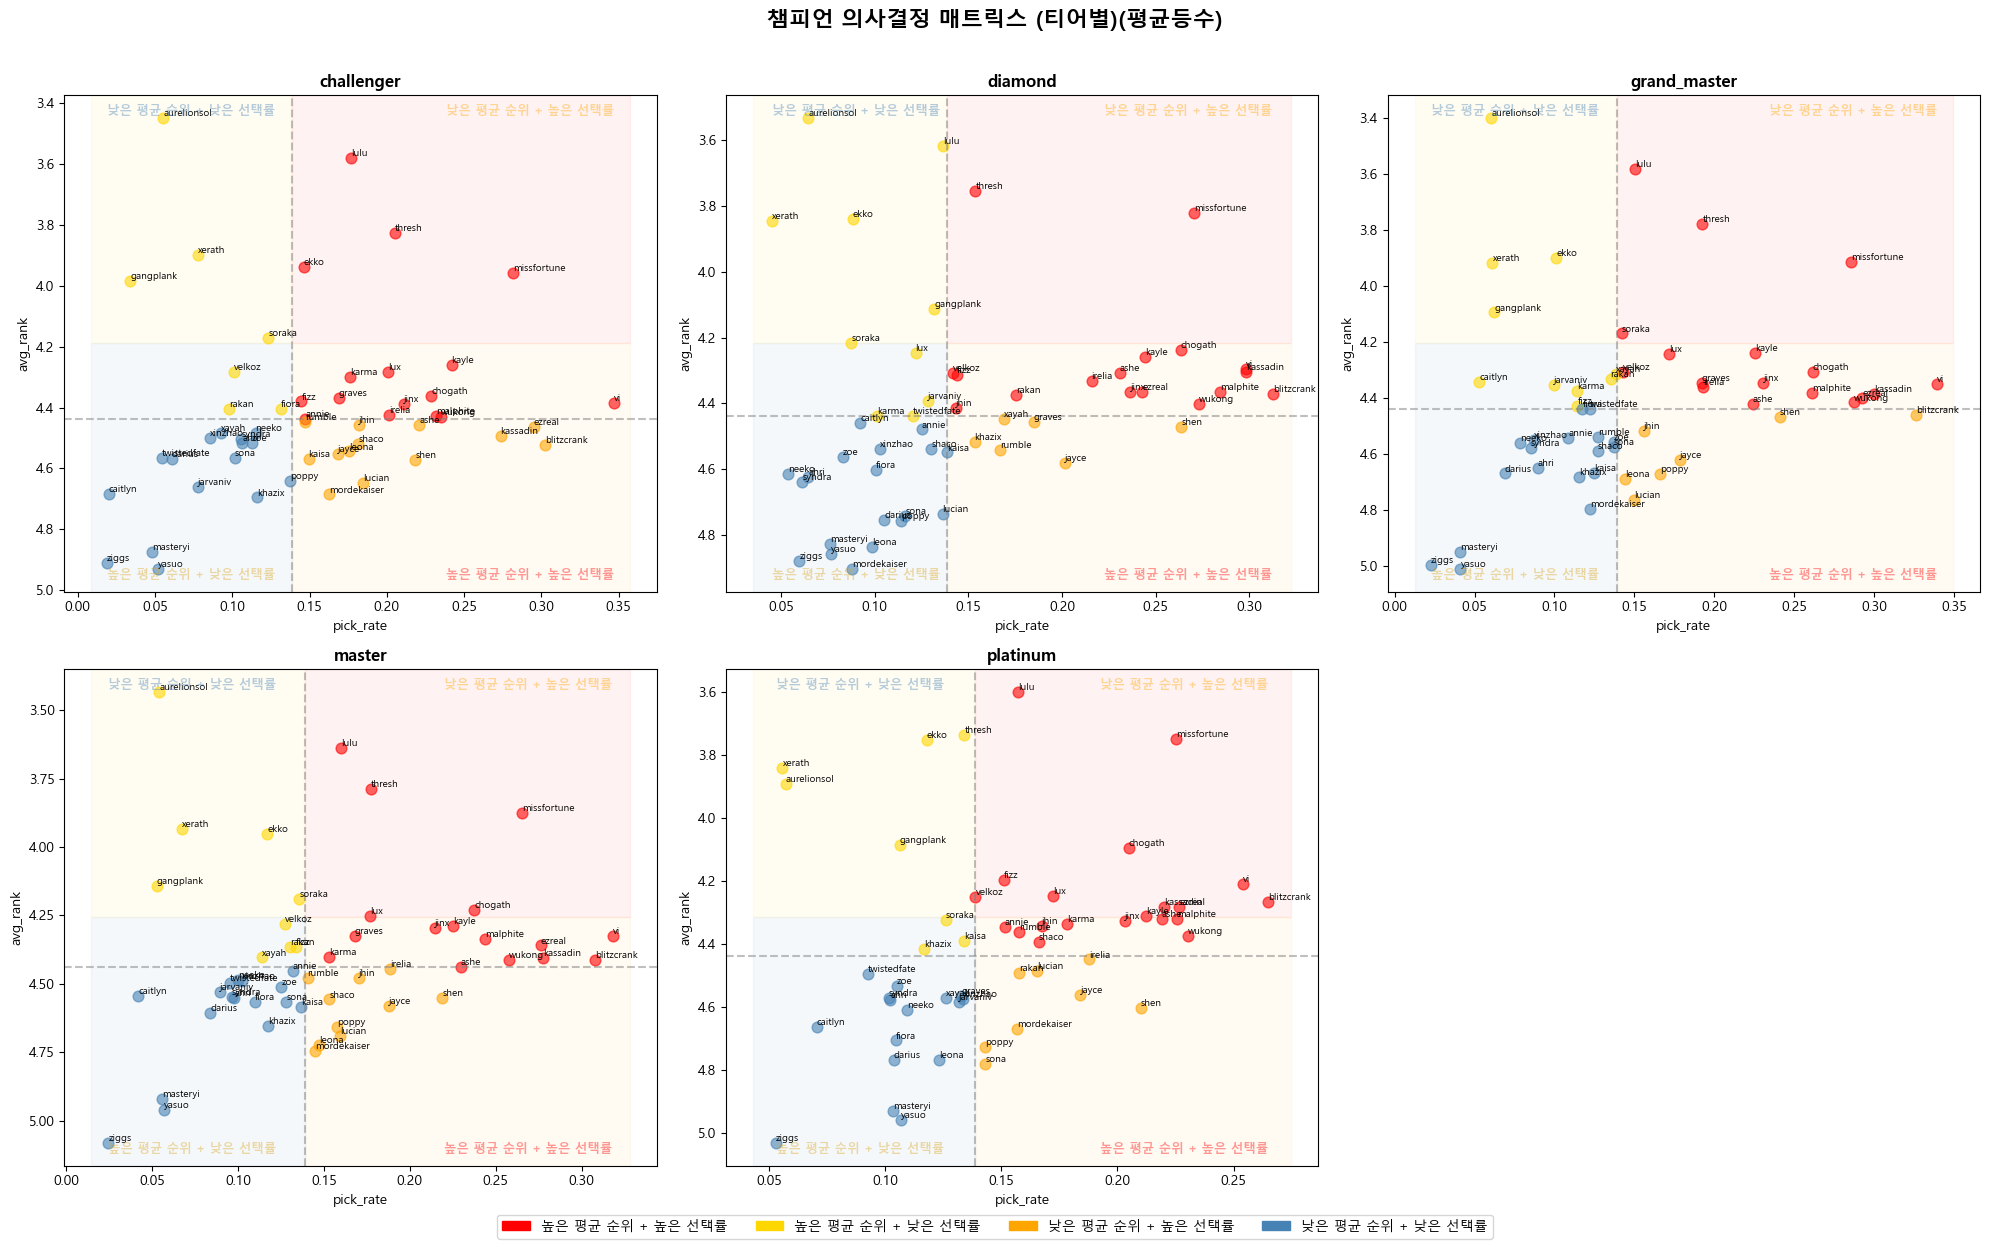

In [32]:
import matplotlib.patches as mpatches

# ================================
# 1. 기준선 설정 (중앙값 기준)
# ================================
avg_rank_median_s  = champ_stats_by_tier_except['avg_rank'].median()
pick_rate_median_s = champ_stats_by_tier_except['pick_rate'].median()

print(f"avg_rank 기준선 (중앙값): {avg_rank_median_s:.3f}")
print(f"pick_rate 기준선 (중앙값): {pick_rate_median_s:.3f}")

# ================================
# 2. 4분면 분류
# ================================
def classify_matrix(row):
    high_rank_s  = row['avg_rank']  <= avg_rank_median_s
    high_pick_s = row['pick_rate'] >= pick_rate_median_s
    
    if high_rank_s and high_pick_s:
        return '높은 평균 순위 + 높은 선택률'
    elif high_rank_s and not high_pick_s:
        return '높은 평균 순위 + 낮은 선택률'
    elif not high_rank_s and high_pick_s:
        return '낮은 평균 순위 + 높은 선택률'
    else:
        return '낮은 평균 순위 + 낮은 선택률'

champ_stats_by_tier_except['matrix_type'] = champ_stats_by_tier_except.apply(classify_matrix, axis=1)

# IQR 이상치 여부도 반영
champ_stats_by_tier_except['is_outlier'] = result_df_1['is_outlier'].values

# ================================
# 3. 표 출력
# ================================
print("\n========== 의사결정 매트릭스 ==========")
for matrix_type in ['높은 평균 순위 + 높은 선택률', '높은 평균 순위 + 낮은 선택률',
                    '낮은 평균 순위 + 높은 선택률', '낮은 평균 순위 + 낮은 선택률']:
    subset = champ_stats_by_tier_except[champ_stats_by_tier_except['matrix_type'] == matrix_type]\
        .sort_values('avg_rank', ascending=True)\
        [['name', 'user_tier', 'avg_rank', 'pick_rate', 'is_outlier']]
    print(f"\n{matrix_type} ({len(subset)}개)")
    print(subset.to_string(index=False))

# ================================
# 4. 시각화 - 티어별 4분면 산점도
# ================================
tiers_s = champ_stats_by_tier_except['user_tier'].unique()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

color_map = {
    '높은 평균 순위 + 높은 선택률': 'red',
    '높은 평균 순위 + 낮은 선택률': 'gold',
    '낮은 평균 순위 + 높은 선택률': 'orange',
    '낮은 평균 순위 + 낮은 선택률': 'steelblue'
}

for i, tier in enumerate(tiers_s):
    ax = axes[i]
    tier_df = champ_stats_by_tier_except[champ_stats_by_tier_except['user_tier'] == tier]
    
    # Y축 범위 미리 계산
    y_min_val = tier_df['avg_rank'].min()
    y_max_val = tier_df['avg_rank'].max()
    
    # 기준선
    ax.axvline(x=pick_rate_median_s, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=avg_rank_median_s,  color='gray', linestyle='--', alpha=0.5)
    
    # 4분면 배경색
    ax.axvspan(pick_rate_median_s, tier_df['pick_rate'].max() + 0.01, 
            ymin=0.5, alpha=0.05, color='red')
    ax.axvspan(tier_df['pick_rate'].min() - 0.01, pick_rate_median_s, 
            ymin=0.5, alpha=0.05, color='gold')
    ax.axvspan(pick_rate_median_s, tier_df['pick_rate'].max() + 0.01, 
            ymax=0.5, alpha=0.05, color='orange')
    ax.axvspan(tier_df['pick_rate'].min() - 0.01, pick_rate_median_s, 
            ymax=0.5, alpha=0.05, color='steelblue')
    
    # 산점도
    for mtype, color in color_map.items():
        subset = tier_df[tier_df['matrix_type'] == mtype]
        ax.scatter(subset['pick_rate'], subset['avg_rank'],
                color=color, alpha=0.6, s=60, label=mtype)

    # 챔피언 이름 표시
    for _, row in tier_df.iterrows():
        ax.annotate(row['name'], (row['pick_rate'], row['avg_rank']),
                    fontsize=7, ha='left', va='bottom')
    
    # 4분면 라벨
    x_min = tier_df['pick_rate'].min()
    x_max = tier_df['pick_rate'].max()
    
    ax.text(x_max, y_max_val, '높은 평균 순위 + 높은 선택률', ha='right', va='top', fontsize=9, color='red', alpha=0.4, fontweight='bold')
    ax.text(x_min, y_max_val, '높은 평균 순위 + 낮은 선택률', ha='left', va='top', fontsize=9, color='goldenrod', alpha=0.4, fontweight='bold')
    ax.text(x_max, y_min_val, '낮은 평균 순위 + 높은 선택률', ha='right', va='bottom', fontsize=9, color='orange', alpha=0.4, fontweight='bold')
    ax.text(x_min, y_min_val, '낮은 평균 순위 + 낮은 선택률', ha='left', va='bottom', fontsize=9, color='steelblue', alpha=0.4, fontweight='bold')
    
    # Y축 뒤집기 (여기에 추가!)
    ax.invert_yaxis()
    
    ax.set_title(f'{tier}', fontsize=12, fontweight='bold')
    ax.set_xlabel('pick_rate')
    ax.set_ylabel('avg_rank')
    
# 빈 subplot 숨기기
for j in range(len(tiers_s), len(axes)):
    axes[j].set_visible(False)

# 범례
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('챔피언 의사결정 매트릭스 (티어별)(평균등수)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# 태블로 대시보드 작업용 계산결과(사분면 제작용)
tier_medians = champ_stats_by_tier_except.groupby('user_tier').agg(
    avg_rank_median=('avg_rank', 'median'),
    pick_rate_median=('pick_rate', 'median')
).reset_index()

print(tier_medians)

      user_tier  avg_rank_median  pick_rate_median
0    challenger         4.461448          0.147178
1       diamond         4.437711          0.133999
2  grand_master         4.425906          0.137143
3        master         4.450374          0.138578
4      platinum         4.393321          0.143057


##### **(2) 티어별 시너지 승률/선택률 분포(의사결정 사분면 제작용)**

In [34]:
# 티어별 중앙값 계산
tier_medians_combo = combo_stats_by_tier_except.groupby('user_tier').agg(
    avg_rank_median=('avg_rank', 'median'),
    pick_rate_median=('pick_rate', 'median')
).reset_index()

print(tier_medians_combo)

      user_tier  avg_rank_median  pick_rate_median
0    challenger         4.311412          0.179231
1       diamond         4.267176          0.180007
2  grand_master         4.325926          0.183342
3        master         4.313707          0.182510
4      platinum         4.216785          0.166099


In [35]:
# 왜도(skewness) 확인 → 0에 가까울수록 정규분포에 가까움
print(f"avg_rank  왜도: {combo_stats_by_tier_except['avg_rank'].skew():.3f}")
print(f"pick_rate 왜도: {combo_stats_by_tier_except['pick_rate'].skew():.3f}")

avg_rank  왜도: -1.234
pick_rate 왜도: 1.114


avg_rank 기준선 (중앙값): 4.292
pick_rate 기준선 (중앙값): 0.179

========== 시너지 의사결정 매트릭스 ==========

높은 평균 순위 + 높은 선택률 (35개)
combo_list_active    user_tier  avg_rank  pick_rate
        Mercenary     platinum  3.883806   0.300795
         Valkyrie      diamond  3.885558   0.181782
        Mercenary       master  3.934085   0.303115
        Mercenary      diamond  3.953098   0.363588
        Mercenary grand_master  3.957731   0.330490
           Mystic   challenger  3.959698   0.185336
        Mercenary   challenger  3.973319   0.304811
         Valkyrie   challenger  3.988850   0.205343
         Valkyrie grand_master  4.003127   0.187956
         Valkyrie       master  4.006786   0.182510
           Mystic       master  4.011801   0.184461
           Mystic grand_master  4.043202   0.184980
       ManaReaver     platinum  4.108875   0.227217
       ManaReaver      diamond  4.155331   0.306992
       ManaReaver grand_master  4.157765   0.304165
           Chrono     platinum  4.169804   0.405842
 

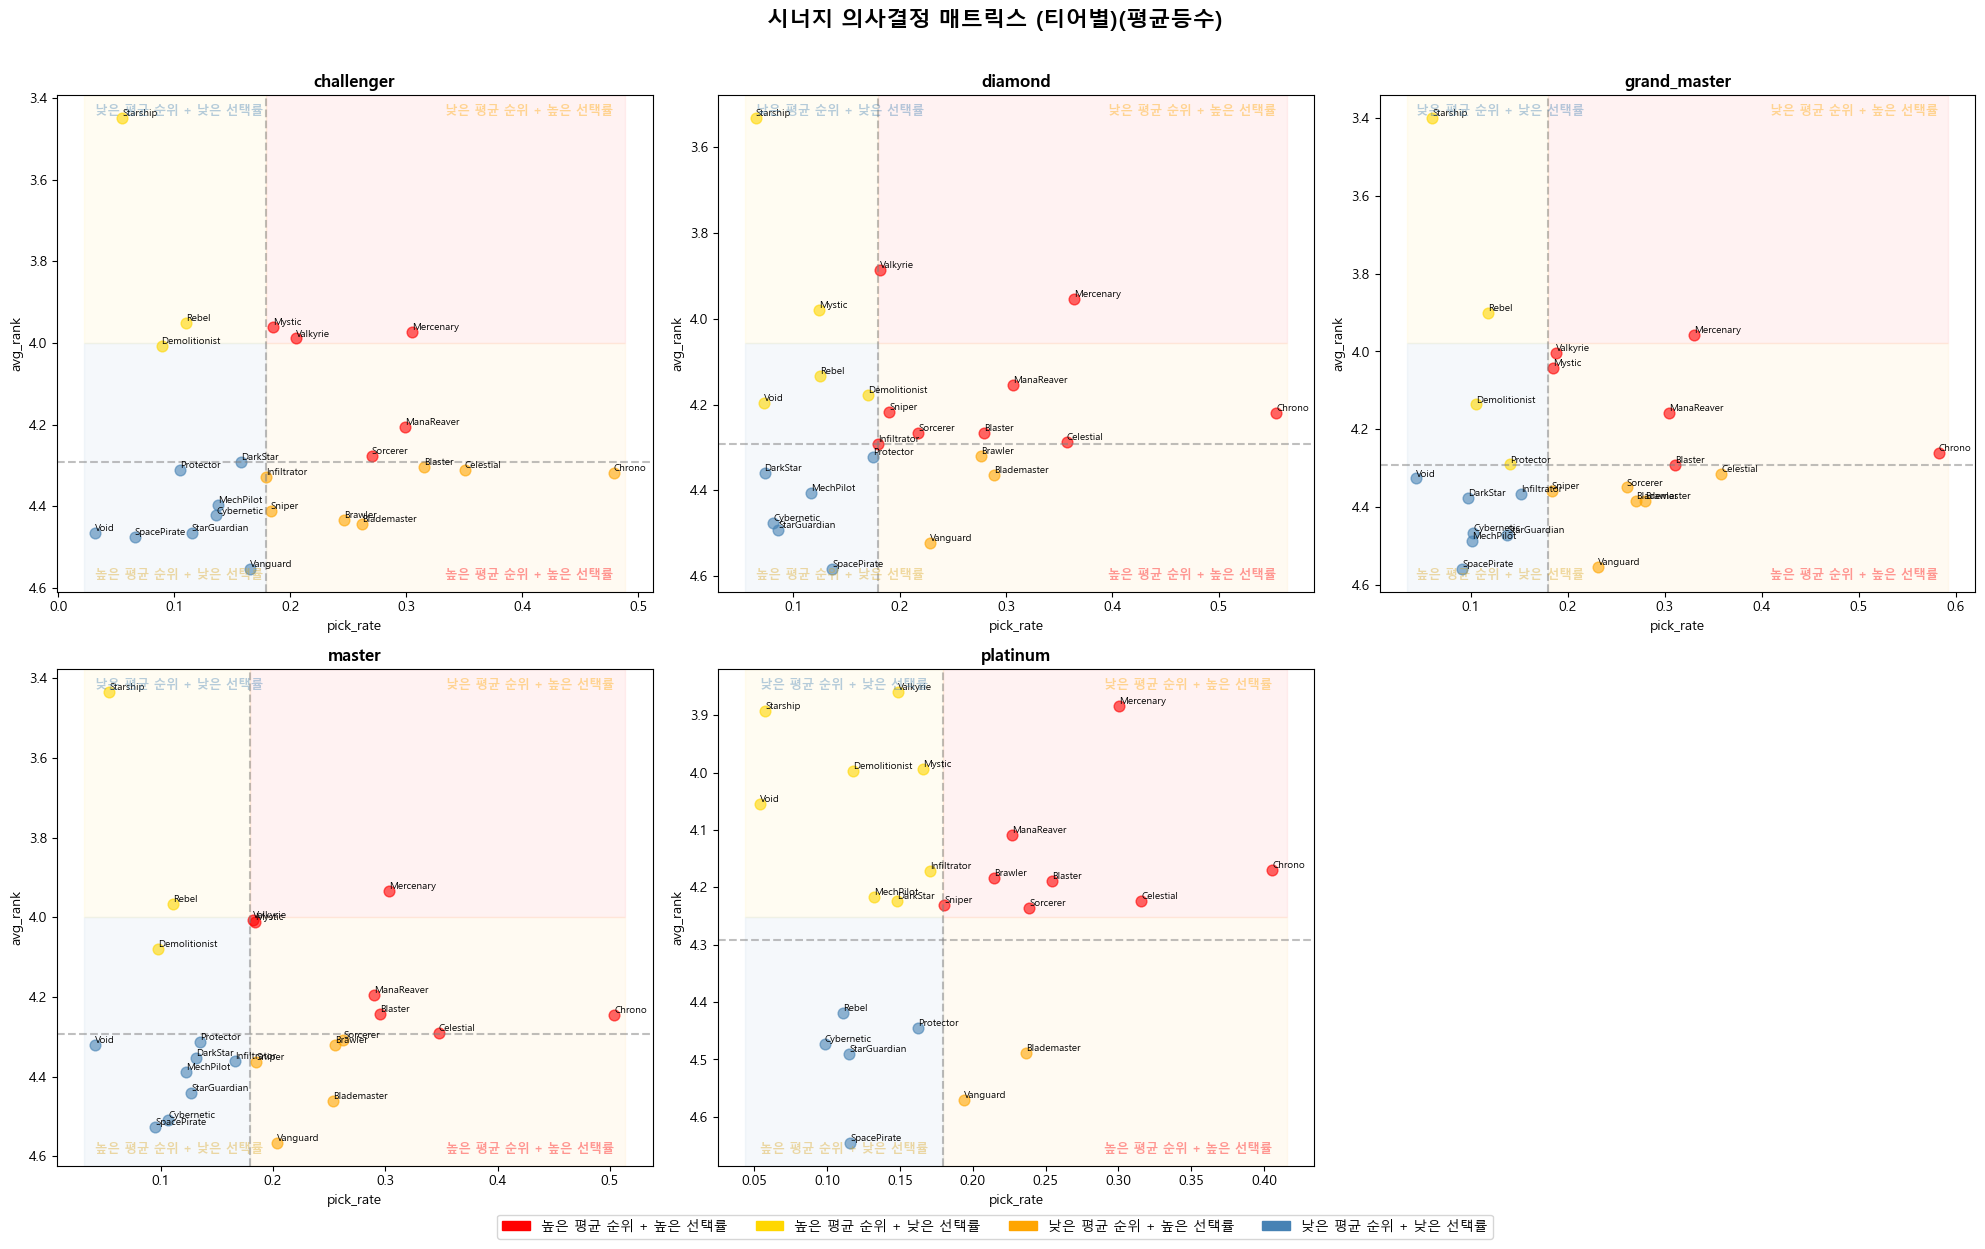

In [36]:
import matplotlib.patches as mpatches

# ================================
# 1. 기준선 설정 (중앙값 기준)
# ================================
avg_rank_median_c  = combo_stats_by_tier_except['avg_rank'].median()
pick_rate_median_c = combo_stats_by_tier_except['pick_rate'].median()

print(f"avg_rank 기준선 (중앙값): {avg_rank_median_c:.3f}")
print(f"pick_rate 기준선 (중앙값): {pick_rate_median_c:.3f}")

# ================================
# 2. 4분면 분류
# ================================
def classify_matrix_combo(row):
    high_rank = row['avg_rank']  <= avg_rank_median_c
    high_pick = row['pick_rate'] >= pick_rate_median_c
    
    if high_rank and high_pick:
        return '높은 평균 순위 + 높은 선택률'
    elif high_rank and not high_pick:
        return '높은 평균 순위 + 낮은 선택률'
    elif not high_rank and high_pick:
        return '낮은 평균 순위 + 높은 선택률'
    else:
        return '낮은 평균 순위 + 낮은 선택률'

combo_stats_by_tier_except['matrix_type'] = combo_stats_by_tier_except.apply(classify_matrix_combo, axis=1)

# ================================
# 3. 표 출력
# ================================
print("\n========== 시너지 의사결정 매트릭스 ==========")
for matrix_type in ['높은 평균 순위 + 높은 선택률', '높은 평균 순위 + 낮은 선택률',
                    '낮은 평균 순위 + 높은 선택률', '낮은 평균 순위 + 낮은 선택률']:
    subset = combo_stats_by_tier_except[combo_stats_by_tier_except['matrix_type'] == matrix_type]\
        .sort_values('avg_rank', ascending=True)\
        [['combo_list_active', 'user_tier', 'avg_rank', 'pick_rate']]
    print(f"\n{matrix_type} ({len(subset)}개)")
    print(subset.to_string(index=False))

# ================================
# 4. 시각화 - 티어별 4분면 산점도
# ================================
tiers_c = combo_stats_by_tier_except['user_tier'].unique()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

color_map = {
    '높은 평균 순위 + 높은 선택률': 'red',
    '높은 평균 순위 + 낮은 선택률': 'gold',
    '낮은 평균 순위 + 높은 선택률': 'orange',
    '낮은 평균 순위 + 낮은 선택률': 'steelblue'
}

for i, tier in enumerate(tiers_c):
    ax = axes[i]
    tier_df = combo_stats_by_tier_except[combo_stats_by_tier_except['user_tier'] == tier]

    # Y축 범위 미리 계산
    y_min_val = tier_df['avg_rank'].min()
    y_max_val = tier_df['avg_rank'].max()

    # 기준선
    ax.axvline(x=pick_rate_median_c, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=avg_rank_median_c,  color='gray', linestyle='--', alpha=0.5)

    # 4분면 배경색
    ax.axvspan(pick_rate_median_c, tier_df['pick_rate'].max() + 0.01,
            ymin=0.5, alpha=0.05, color='red')
    ax.axvspan(tier_df['pick_rate'].min() - 0.01, pick_rate_median_c,
            ymin=0.5, alpha=0.05, color='gold')
    ax.axvspan(pick_rate_median_c, tier_df['pick_rate'].max() + 0.01,
            ymax=0.5, alpha=0.05, color='orange')
    ax.axvspan(tier_df['pick_rate'].min() - 0.01, pick_rate_median_c,
            ymax=0.5, alpha=0.05, color='steelblue')

    # 산점도
    for mtype, color in color_map.items():
        subset = tier_df[tier_df['matrix_type'] == mtype]
        ax.scatter(subset['pick_rate'], subset['avg_rank'],
                color=color, alpha=0.6, s=60, label=mtype)

    # 시너지 이름 표시 (모든 점)
    for _, row in tier_df.iterrows():
        ax.annotate(row['combo_list_active'], (row['pick_rate'], row['avg_rank']),
                    fontsize=7, ha='left', va='bottom')

    # 4분면 라벨
    x_min = tier_df['pick_rate'].min()
    x_max = tier_df['pick_rate'].max()
    
    ax.text(x_max, y_max_val, '높은 평균 순위 + 높은 선택률', ha='right', va='top',   fontsize=9, color='red',       alpha=0.4, fontweight='bold')
    ax.text(x_min, y_max_val, '높은 평균 순위 + 낮은 선택률', ha='left',  va='top',   fontsize=9, color='goldenrod', alpha=0.4, fontweight='bold')
    ax.text(x_max, y_min_val, '낮은 평균 순위 + 높은 선택률', ha='right', va='bottom', fontsize=9, color='orange',   alpha=0.4, fontweight='bold')
    ax.text(x_min, y_min_val, '낮은 평균 순위 + 낮은 선택률', ha='left',  va='bottom', fontsize=9, color='steelblue',alpha=0.4, fontweight='bold')

    # Y축 뒤집기 (여기에 추가!)
    ax.invert_yaxis()

    ax.set_title(f'{tier}', fontsize=12, fontweight='bold')
    ax.set_xlabel('pick_rate')
    ax.set_ylabel('avg_rank')

# 빈 subplot 숨기기
for j in range(len(tiers_c), len(axes)):
    axes[j].set_visible(False)

# 범례
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('시너지 의사결정 매트릭스 (티어별)(평균등수)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()